In [1]:
# Проверяем, есть ли GPU. Без него обучение будет в десятки раз медленнее.
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
if result.returncode == 0:
    print(f'GPU: {result.stdout.strip()}')
else:
    print('GPU не найден. Перейди в Runtime -> Change runtime type -> T4 GPU')

GPU: NVIDIA A100-SXM4-40GB, 40960 MiB


In [2]:
# Импортируем все нужные библиотеки.
import os, copy, shutil, random, tarfile, json
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
from torchvision import datasets, transforms, models

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : NVIDIA A100-SXM4-40GB


In [3]:
# Фиксируем случайность — при повторном запуске с тем же seed результаты будут одинаковыми.
MY_SEED = 50

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(MY_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cuda


In [4]:
# Все пути и гиперпараметры в одном месте. Менять нужно только здесь.
BASE_DIR         = '/content'
STANFORD_DIR     = f'{BASE_DIR}/stanford_dogs'       # изображения
STANFORD_ANN_DIR = f'{BASE_DIR}/stanford_annotations' # XML bboxes
TSINGHUA_DIR     = f'{BASE_DIR}/tsinghua_dogs'        # изображения
MERGED_DIR       = f'{BASE_DIR}/merged_dogs'          # объединённый датасет
CHECKPOINT_PATH  = f'{BASE_DIR}/best_model.pt'

IMG_SIZE   = 300   # нативный размер EfficientNet-B3
BATCH_SIZE = 32
MIN_IMGS_PER_CLASS = 50  # удалять классы с меньшим числом фото

print('Конфигурация задана')
print(f'  IMG_SIZE   = {IMG_SIZE}')
print(f'  BATCH_SIZE = {BATCH_SIZE}')

Конфигурация задана
  IMG_SIZE   = 300
  BATCH_SIZE = 32


## Скачивание датасетов

### Stanford Dogs
Официальный датасет Stanford (~800 MB): 120 пород, ~20 000 изображений, XML аннотации с bbox.

### Tsinghua Dogs 
Крупнейший датасет пород собак (~3.5 GB): 130 пород, 70 000+ изображений.

> ⏱ **Оценка времени**: Stanford ~2 мин, Tsinghua ~10 мин (зависит от скорости сервера Colab)

In [5]:
# Скачиваем Stanford Dogs: фотографии (~800 MB) и XML-файлы с координатами собак (~20 MB).
import urllib.request

def download_with_progress(url, dest_path, desc=''):
    """Скачивает файл с прогрессом."""
    if os.path.exists(dest_path):
        print(f'  Уже скачан: {dest_path}')
        return

    print(f'  Скачиваем {desc}...')
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)

    def reporthook(count, block_size, total_size):
        if total_size > 0:
            pct = count * block_size * 100 / total_size
            mb_done = count * block_size / 1024 / 1024
            mb_total = total_size / 1024 / 1024
            print(f'\r    {pct:.1f}% ({mb_done:.0f}/{mb_total:.0f} MB)', end='', flush=True)

    urllib.request.urlretrieve(url, dest_path, reporthook)
    print(f'\n   Сохранён: {dest_path}')

def extract_tar(tar_path, extract_to, desc=''):
    """Распаковывает .tar или .tar.gz архив."""
    print(f'  Распаковываем {desc}...')
    with tarfile.open(tar_path) as tar:
        tar.extractall(extract_to)
    print(f'   Распакован в {extract_to}')

stanford_img_tar  = f'{BASE_DIR}/stanford_images.tar'
stanford_ann_tar  = f'{BASE_DIR}/stanford_annotations.tar'

if not os.path.exists(STANFORD_DIR) or len(os.listdir(STANFORD_DIR)) < 10:
    download_with_progress(
        'http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar',
        stanford_img_tar,
        'Stanford Dogs Images (~800 MB)'
    )
    extract_tar(stanford_img_tar, BASE_DIR, 'Stanford Images')
    extracted = os.path.join(BASE_DIR, 'Images')
    if os.path.exists(extracted):
        os.rename(extracted, STANFORD_DIR)
    os.remove(stanford_img_tar)
else:
    print(f'Stanford Images уже распакованы ({len(os.listdir(STANFORD_DIR))} классов)')

if not os.path.exists(STANFORD_ANN_DIR) or len(os.listdir(STANFORD_ANN_DIR)) < 10:
    download_with_progress(
        'http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar',
        stanford_ann_tar,
        'Stanford Annotations (~20 MB)'
    )
    extract_tar(stanford_ann_tar, BASE_DIR, 'Stanford Annotations')
    extracted = os.path.join(BASE_DIR, 'Annotation')
    if os.path.exists(extracted):
        os.rename(extracted, STANFORD_ANN_DIR)
    os.remove(stanford_ann_tar)
else:
    print(f'Stanford Annotations уже распакованы ({len(os.listdir(STANFORD_ANN_DIR))} классов)')

print(f'\nStanford Dogs: {sum(len(os.listdir(os.path.join(STANFORD_DIR, d))) for d in os.listdir(STANFORD_DIR) if os.path.isdir(os.path.join(STANFORD_DIR, d))):,} изображений')

  Скачиваем Stanford Dogs Images (~800 MB)...
    100.0% (757/757 MB)
  Сохранён: /content/stanford_images.tar
  Распаковываем Stanford Images...


/tmp/ipykernel_3732/530072705.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_to)


  Распакован в /content
  Скачиваем Stanford Annotations (~20 MB)...
    100.0% (21/21 MB)
  Сохранён: /content/stanford_annotations.tar
  Распаковываем Stanford Annotations...
  Распакован в /content

Stanford Dogs: 20,580 изображений


In [7]:
# parse_stanford_bbox читает XML и возвращает координаты рамки вокруг собаки.
# crop_with_bbox вырезает собаку с небольшим отступом — убираем лишний фон.
# normalize_breed приводит названия пород к единому виду для объединения датасетов.
def parse_stanford_bbox(ann_path):
    """Читает XML Stanford и возвращает (xmin, ymin, xmax, ymax) или None."""
    try:
        root = ET.parse(ann_path).getroot()
        obj  = root.find('object')
        if obj is None:
            return None
        b = obj.find('bndbox')
        if b is None:
            return None
        return (int(b.find('xmin').text), int(b.find('ymin').text),
                int(b.find('xmax').text), int(b.find('ymax').text))
    except Exception:
        return None

def crop_with_bbox(img, bbox, margin=0.1):
    """Кроп по bbox + margin 10% — сохраняет немного контекста вокруг собаки."""
    W, H = img.size
    x1, y1, x2, y2 = bbox
    bw, bh = x2 - x1, y2 - y1
    x1 = max(0, int(x1 - bw * margin))
    y1 = max(0, int(y1 - bh * margin))
    x2 = min(W, int(x2 + bw * margin))
    y2 = min(H, int(y2 + bh * margin))
    return img.crop((x1, y1, x2, y2))

def normalize_breed(name):
    """
    Нормализует имя породы для объединения датасетов:
    'n02085620-Chihuahua' → 'chihuahua'
    'Afghan_Hound'        → 'afghan_hound'
    """
    if '-' in name:                             # убираем ImageNet prefix
        name = name.split('-', 1)[1]
    return name.lower().replace(' ', '_').replace('-', '_')

assert normalize_breed('n02085620-Chihuahua') == 'chihuahua'
assert normalize_breed('Afghan_Hound') == 'afghan_hound'
print('Утилиты готовы ')

Утилиты готовы 


In [8]:
# Копируем фото из Stanford и Tsinghua в одну папку merged_dogs/.
# Породы с одинаковым именем из разных датасетов попадают в одну папку — больше данных на класс.
def build_merged_dataset(stanford_img, stanford_ann, tsinghua, output,
                          use_tsinghua=True):
    os.makedirs(output, exist_ok=True)
    counts = {'stanford': 0, 'tsinghua': 0}

    print(' Обрабатываем Stanford Dogs...')
    for breed_dir in tqdm(sorted(os.listdir(stanford_img))):
        src_breed = os.path.join(stanford_img, breed_dir)
        if not os.path.isdir(src_breed):
            continue
        breed = normalize_breed(breed_dir)
        dst_breed = os.path.join(output, breed)
        os.makedirs(dst_breed, exist_ok=True)

        for fname in os.listdir(src_breed):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            dst = os.path.join(dst_breed, f's_{fname}')
            if os.path.exists(dst):
                continue
            try:
                img = Image.open(os.path.join(src_breed, fname)).convert('RGB')
                stem = os.path.splitext(fname)[0]
                for ann_path in [
                    os.path.join(stanford_ann, breed_dir, stem),
                    os.path.join(stanford_ann, breed_dir, stem + '.xml')
                ]:
                    if os.path.exists(ann_path):
                        bbox = parse_stanford_bbox(ann_path)
                        if bbox:
                            img = crop_with_bbox(img, bbox)
                        break
                img.save(dst, 'JPEG', quality=95)
                counts['stanford'] += 1
            except Exception:
                pass

    if use_tsinghua and os.path.exists(tsinghua):
        print(' Обрабатываем Tsinghua Dogs...')
        for breed_dir in tqdm(sorted(os.listdir(tsinghua))):
            src_breed = os.path.join(tsinghua, breed_dir)
            if not os.path.isdir(src_breed):
                continue
            breed = normalize_breed(breed_dir)
            dst_breed = os.path.join(output, breed)
            os.makedirs(dst_breed, exist_ok=True)

            for fname in os.listdir(src_breed):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue
                dst = os.path.join(dst_breed, f't_{fname}')
                if not os.path.exists(dst):
                    try:
                        shutil.copy2(os.path.join(src_breed, fname), dst)
                        counts['tsinghua'] += 1
                    except Exception:
                        pass

    total = counts['stanford'] + counts['tsinghua']
    n_classes = len([d for d in os.listdir(output) if os.path.isdir(os.path.join(output, d))])
    print(f'\n Готово: Stanford {counts["stanford"]:,} + Tsinghua {counts["tsinghua"]:,} = {total:,} изображений, {n_classes} пород')
    return counts

already_merged = (
    os.path.exists(MERGED_DIR) and
    len([d for d in os.listdir(MERGED_DIR) if os.path.isdir(os.path.join(MERGED_DIR, d))]) > 10
)

if not already_merged:
    build_merged_dataset(
        STANFORD_DIR, STANFORD_ANN_DIR, TSINGHUA_DIR, MERGED_DIR,
        use_tsinghua=USE_TSINGHUA
    )
else:
    n_cls = len([d for d in os.listdir(MERGED_DIR) if os.path.isdir(os.path.join(MERGED_DIR, d))])
    print(f'Датасет уже собран: {n_cls} классов в {MERGED_DIR}')

Обрабатываем Stanford Dogs...



Готово: Stanford 20,580 + Tsinghua 0 = 20,580 изображений, 120 пород


Всего пород:        120
Всего изображений:  20,580
Среднее / класс:    171
Макс / класс:       252
Мин / класс:        148


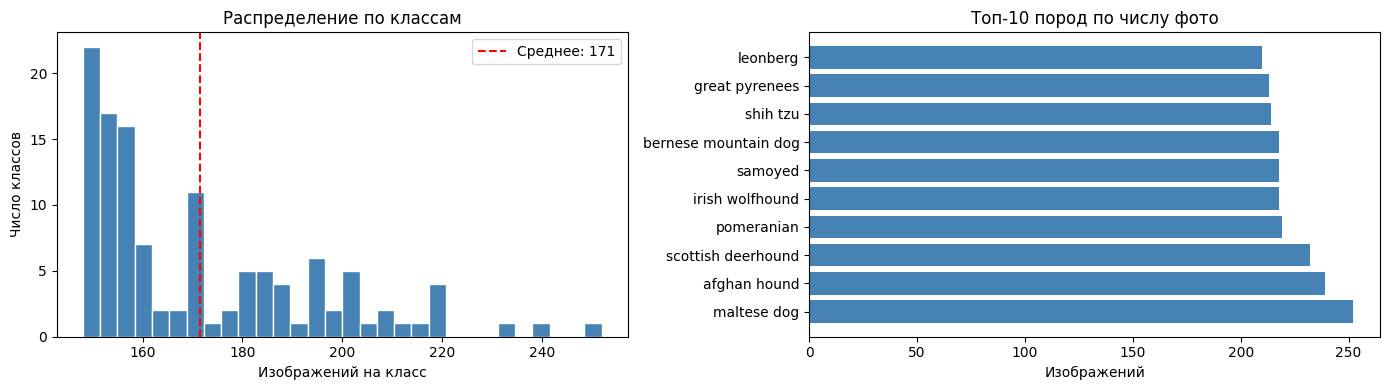

In [9]:
# Считаем число фото на каждую породу. Удаляем классы с менее чем MIN_IMGS_PER_CLASS фото.
breed_counts = {
    d: len(os.listdir(os.path.join(MERGED_DIR, d)))
    for d in os.listdir(MERGED_DIR)
    if os.path.isdir(os.path.join(MERGED_DIR, d))
}

counts_list = sorted(breed_counts.values(), reverse=True)
total_imgs  = sum(counts_list)

print(f'Всего пород:        {len(breed_counts)}')
print(f'Всего изображений:  {total_imgs:,}')
print(f'Среднее / класс:    {total_imgs // len(breed_counts)}')
print(f'Макс / класс:       {max(counts_list)}')
print(f'Мин / класс:        {min(counts_list)}')

# Удаляем классы с < MIN_IMGS_PER_CLASS
to_remove = [b for b, c in breed_counts.items() if c < MIN_IMGS_PER_CLASS]
if to_remove:
    print(f'\nУдаляем {len(to_remove)} классов с < {MIN_IMGS_PER_CLASS} фото...')
    for b in to_remove:
        shutil.rmtree(os.path.join(MERGED_DIR, b))
    breed_counts = {k: v for k, v in breed_counts.items() if k not in to_remove}
    print(f'Осталось: {len(breed_counts)} классов')

# Гистограмма
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(list(breed_counts.values()), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(list(breed_counts.values())), color='red', linestyle='--',
                label=f'Среднее: {int(np.mean(list(breed_counts.values())))}')
axes[0].set_xlabel('Изображений на класс')
axes[0].set_ylabel('Число классов')
axes[0].set_title('Распределение по классам')
axes[0].legend()

top10 = sorted(breed_counts.items(), key=lambda x: x[1], reverse=True)[:10]
axes[1].barh([x[0].replace('_',' ')[:25] for x in top10],
             [x[1] for x in top10], color='steelblue')
axes[1].set_xlabel('Изображений')
axes[1].set_title('Топ-10 пород по числу фото')
plt.tight_layout()
plt.show()

In [10]:
# train_transform разнообразит картинки на каждой эпохе: случайный кроп, перевороты, цвет.
# val_transform — только стандартная нарезка без случайностей.
# tta_transforms — три фиксированных варианта одного фото для усреднения на тесте.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 1.15)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 1.3)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
]

print('Трансформы готовы ')

Трансформы готовы 


In [11]:
# TransformSubset нужен, чтобы train и val применяли разные трансформы к одному датасету.
# WeightedRandomSampler выравнивает дисбаланс классов:
# редкие породы семплируются так же часто, как многочисленные.
class TransformSubset(Dataset):
    """Subset с независимым transform — train и val получают разные аугментации."""
    def __init__(self, dataset, indices, transform=None):
        self.dataset   = dataset
        self.indices   = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

base_dataset = datasets.ImageFolder(root=MERGED_DIR, transform=transforms.Compose([]))
num_classes  = len(base_dataset.classes)
class_names  = base_dataset.classes

print(f'Классов: {num_classes} | Изображений: {len(base_dataset):,}')

N          = len(base_dataset)
train_size = int(0.70 * N)
val_size   = int(0.15 * N)
test_size  = N - train_size - val_size

gen = torch.Generator().manual_seed(MY_SEED)
train_idx, val_idx, test_idx = random_split(range(N), [train_size, val_size, test_size], generator=gen)

train_dataset = TransformSubset(base_dataset, train_idx, train_transform)
val_dataset   = TransformSubset(base_dataset, val_idx,   val_transform)
test_dataset  = TransformSubset(base_dataset, test_idx,  val_transform)

train_labels  = [base_dataset.targets[i] for i in train_idx]
class_counts  = Counter(train_labels)
sample_weights = [1.0 / class_counts[base_dataset.targets[i]] for i in train_idx]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}')

Классов: 120 | Изображений: 20,580
Train: 14,405 | Val: 3,087 | Test: 3,088


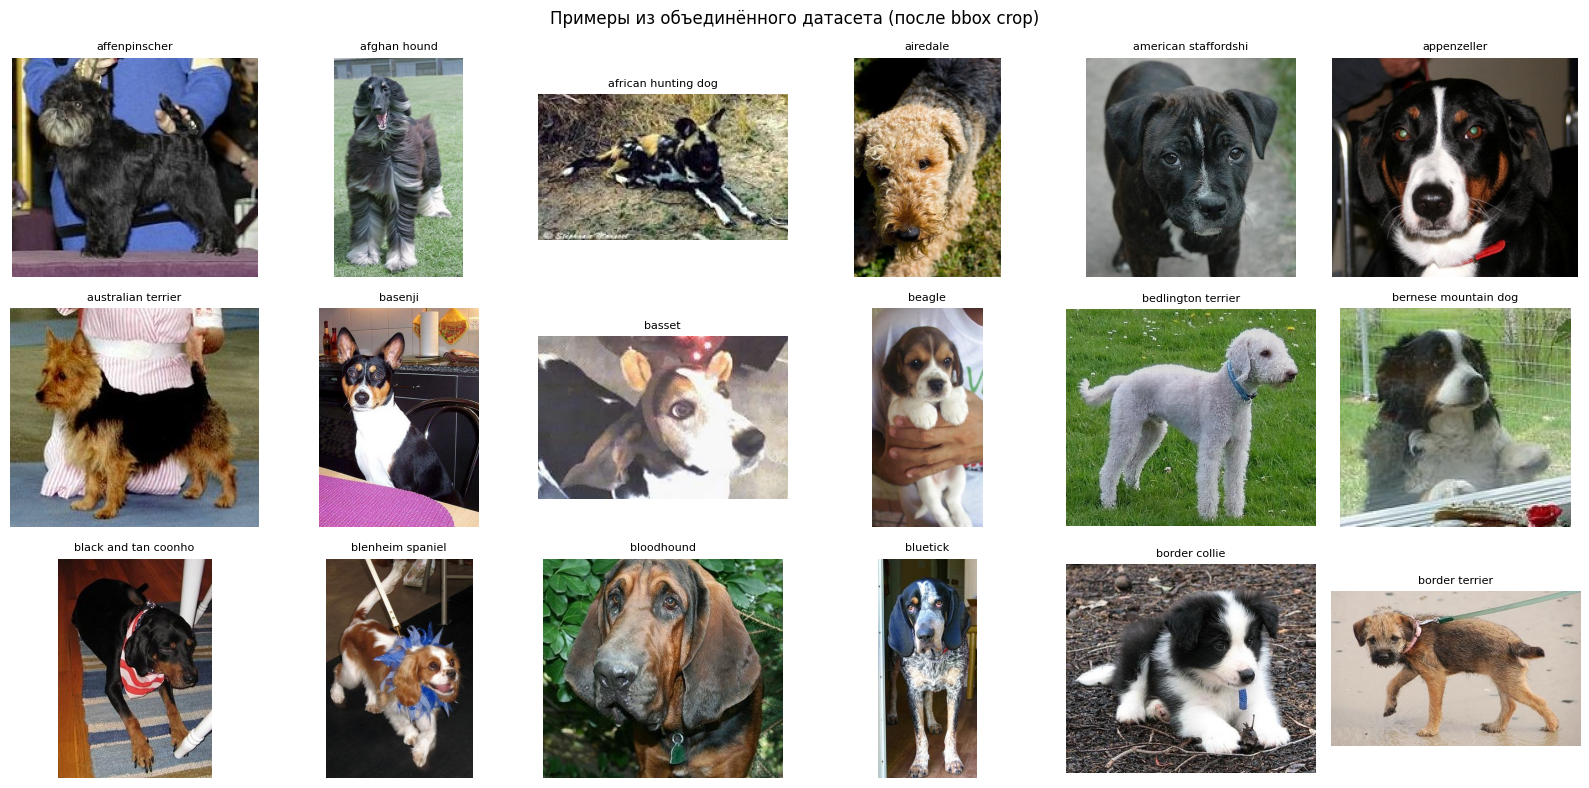

In [12]:
# Показываем по одному примеру из каждой породы, чтобы убедиться что данные выглядят правильно.
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

shown = set()
plot_i = 0
for idx in range(len(base_dataset)):
    label = base_dataset.targets[idx]
    if label in shown or plot_i >= 18:
        continue
    img, _ = base_dataset[idx]
    axes[plot_i].imshow(img)
    axes[plot_i].set_title(class_names[label].replace('_', ' ')[:20], fontsize=8)
    axes[plot_i].axis('off')
    shown.add(label)
    plot_i += 1
    if plot_i >= 18:
        break

plt.suptitle('Примеры из объединённого датасета (после bbox crop)', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# EfficientNet-B3 — сеть, предобученная на ImageNet. Заменяем только последний слой под наши классы.
# Два Dropout-а снижают переобучение.
# get_param_groups задаёт разные lr: backbone учится медленно, новый head — быстрее.
class DogEfficientNetB3(nn.Module):
    def __init__(self, num_classes, dropout_p=0.4):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p, inplace=True),
            nn.Linear(in_features, 512),
            nn.SiLU(),           # EfficientNet нативно использует SiLU (Swish)
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_p * 0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

def get_param_groups(model, head_lr=5e-4, backbone_lr=5e-5):
    """Разные lr для backbone и head (differential learning rates)."""
    head_ids    = {id(p) for p in model.backbone.classifier.parameters()}
    backbone_ps = [p for p in model.parameters() if id(p) not in head_ids]
    head_ps     = list(model.backbone.classifier.parameters())
    return [
        {'params': backbone_ps, 'lr': backbone_lr},
        {'params': head_ps,     'lr': head_lr}
    ]

model = DogEfficientNetB3(num_classes=num_classes, dropout_p=0.4).to(device)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметров всего:    {total:,}')
print(f'Обучаемых:           {trainable:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 146MB/s]


Параметров всего:    11,545,760
Обучаемых:           11,545,760


In [14]:
# Mixup: смешиваем два изображения и их метки в пропорции lam/(1-lam).
# CutMix: вырезаем прямоугольник из одного фото, вставляем в другое. Метки — пропорционально площади.
# Оба метода снижают переобучение лучше, чем стандартные аугментации.
def mixup_batch(images, labels, num_classes, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    la = F.one_hot(labels, num_classes).float()
    lb = F.one_hot(labels[idx], num_classes).float()
    return mixed, lam * la + (1 - lam) * lb

def cutmix_batch(images, labels, num_classes, alpha=1.0):
    lam  = np.random.beta(alpha, alpha)
    B, _, H, W = images.shape
    idx  = torch.randperm(B, device=images.device)
    r    = np.sqrt(1.0 - lam)
    cw, ch = int(W * r), int(H * r)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = max(0, cx - cw//2), min(W, cx + cw//2)
    y1, y2 = max(0, cy - ch//2), min(H, cy + ch//2)
    mixed  = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    lam = 1.0 - (x2 - x1) * (y2 - y1) / (W * H)
    la  = F.one_hot(labels, num_classes).float()
    lb  = F.one_hot(labels[idx], num_classes).float()
    return mixed, lam * la + (1 - lam) * lb

print('Mixup / CutMix готовы ')

Mixup / CutMix готовы 


In [15]:
# train_one_epoch: один проход по train-датасету с обновлением весов.
# evaluate: loss и accuracy по val/test без изменения весов.
# evaluate_tta: несколько проходов с разными трансформами, вероятности усредняются.
def soft_ce(logits, soft_labels):
    """Cross-entropy для мягких меток (Mixup/CutMix)."""
    return -(soft_labels * F.log_softmax(logits, dim=1)).sum(dim=1).mean()

def train_one_epoch(model, loader, optimizer, device, num_classes,
                    use_mixup=True, mixup_alpha=0.4, cutmix_prob=0.3):
    model.train()
    total_loss = correct = total = 0

    for images, labels in tqdm(loader, leave=False, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        soft = False

        if use_mixup:
            r = random.random()
            if r < cutmix_prob:
                images, sl = cutmix_batch(images, labels, num_classes)
                soft = True
            elif r < cutmix_prob + 0.3:
                images, sl = mixup_batch(images, labels, num_classes, mixup_alpha)
                soft = True

        optimizer.zero_grad()
        logits = model(images)

        if soft:
            sl = sl * 0.95 + 0.05 / num_classes   # label smoothing поверх soft labels
            loss = soft_ce(logits, sl)
            correct += (logits.argmax(1) == sl.argmax(1)).sum().item()
        else:
            loss = F.cross_entropy(logits, labels, label_smoothing=0.1)
            correct += (logits.argmax(1) == labels).sum().item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total      += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = correct = total = 0

    for images, labels in tqdm(loader, leave=False, desc='Val'):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        total_loss += F.cross_entropy(logits, labels).item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate_tta(model, dataset, device, tta_tfms, batch_size=32):
    """TTA: усредняем softmax-вероятности по N трансформам → финальный argmax."""
    model.eval()
    all_probs  = []
    all_labels = None

    for t_i, tfm in enumerate(tta_tfms):
        original_tfm    = dataset.transform
        dataset.transform = tfm
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
        probs_list, labels_list = [], []

        for images, labels in tqdm(loader, leave=False, desc=f'TTA {t_i+1}/{len(tta_tfms)}'):
            probs_list.append(F.softmax(model(images.to(device)), dim=1).cpu())
            labels_list.extend(labels.numpy())

        all_probs.append(torch.cat(probs_list, dim=0))
        if all_labels is None:
            all_labels = np.array(labels_list)
        dataset.transform = original_tfm

    avg_probs = torch.stack(all_probs).mean(0)
    preds     = avg_probs.argmax(1).numpy()
    return (preds == all_labels).mean(), preds, all_labels

print('Функции обучения готовы ')

Функции обучения готовы 


In [16]:
# Следим за val_loss. Если не улучшается patience эпох подряд — останавливаем обучение.
# Лучшие веса сохраняются при каждом улучшении и восстанавливаются в конце.
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, save_path=CHECKPOINT_PATH):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
            torch.save(self.best_state, self.save_path)
            return False
        self.counter += 1
        return self.counter >= self.patience

    def load_best(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f'Загружены лучшие веса (val_loss={self.best_loss:.4f})')

print('EarlyStopping готов ')

EarlyStopping готов

In [17]:
# Фаза 1: backbone заморожен, учим только новый classifier.
# Нужно, чтобы classifier получил разумные начальные веса
# до того, как мы начнём изменять backbone.
PHASE1_EPOCHS = 5

for name, p in model.backbone.named_parameters():
    p.requires_grad = ('classifier' in name)

n_frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Фаза 1: заморожено {n_frozen:,}, учится {n_trainable:,} параметров')

opt1  = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=1e-3, weight_decay=1e-4)
sch1  = torch.optim.lr_scheduler.OneCycleLR(
    opt1, max_lr=1e-3, epochs=PHASE1_EPOCHS, steps_per_epoch=len(train_loader))

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'\n=== Фаза 1: Head warm-up ({PHASE1_EPOCHS} эпох) ===')
for epoch in range(PHASE1_EPOCHS):
    tl, ta = train_one_epoch(model, train_loader, opt1, device, num_classes, use_mixup=False)
    vl, va = evaluate(model, val_loader, device)
    sch1.step()
    for k, v in zip(['train_loss','train_acc','val_loss','val_acc'], [tl,ta,vl,va]):
        history[k].append(v)
    print(f'  [{epoch+1}/{PHASE1_EPOCHS}] train_acc={ta:.4f} | val_acc={va:.4f}')

print('Фаза 1 завершена ')

Фаза 1: заморожено 10,696,232, учится 849,528 параметров

=== Фаза 1: Head warm-up (5 эпох) ===


  [1/5] train_acc=0.2037 | val_acc=0.6025


  [2/5] train_acc=0.4995 | val_acc=0.7153


  [3/5] train_acc=0.6031 | val_acc=0.7638


  [4/5] train_acc=0.6432 | val_acc=0.7888


  [5/5] train_acc=0.6594 | val_acc=0.7849
Фаза 1 завершена 


In [18]:
# Фаза 2: размораживаем весь backbone и учим всю сеть. 
# Backbone получает маленький lr (5e-5), чтобы не разрушить ImageNet-веса.
# CosineAnnealingWarmRestarts периодически поднимает lr — помогает не застрять в локальном минимуме.
PHASE2_EPOCHS = 10

for p in model.parameters():
    p.requires_grad = True

print(f'Фаза 2: разморожены все {sum(p.numel() for p in model.parameters()):,} параметров')

opt2 = torch.optim.AdamW(
    get_param_groups(model, head_lr=5e-4, backbone_lr=5e-5),
    weight_decay=1e-4
)
sch2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt2, T_0=15, T_mult=2, eta_min=1e-7
)
stopper = EarlyStopping(patience=12, save_path=CHECKPOINT_PATH)

print(f'\n=== Фаза 2: Full fine-tuning (до {PHASE2_EPOCHS} эпох) ===')
for epoch in range(PHASE2_EPOCHS):
    tl, ta = train_one_epoch(model, train_loader, opt2, device, num_classes,
                              use_mixup=True, mixup_alpha=0.4, cutmix_prob=0.3)
    vl, va = evaluate(model, val_loader, device)
    sch2.step()

    for k, v in zip(['train_loss','train_acc','val_loss','val_acc'], [tl,ta,vl,va]):
        history[k].append(v)

    lr_now = opt2.param_groups[1]['lr']
    marker = ' ' if vl <= stopper.best_loss else ''
    print(f'  [{epoch+1:3d}/{PHASE2_EPOCHS}] '
          f'train_acc={ta:.4f} loss={tl:.4f} | '
          f'val_acc={va:.4f} loss={vl:.4f} | '
          f'lr={lr_now:.1e}{marker}')

    if stopper.step(vl, model):
        print(f'  → Early stopping на эпохе {epoch+1}')
        break

stopper.load_best(model)

Фаза 2: разморожены все 11,545,760 параметров

=== Фаза 2: Full fine-tuning (до 10 эпох) ===


  [  1/10] train_acc=0.6603 loss=2.1103 | val_acc=0.8581 loss=0.5999 | lr=4.9e-04 


  [  2/10] train_acc=0.7225 loss=1.9565 | val_acc=0.8743 loss=0.5356 | lr=4.8e-04 


  [  3/10] train_acc=0.7602 loss=1.8516 | val_acc=0.8792 loss=0.5210 | lr=4.5e-04 


  [  4/10] train_acc=0.7701 loss=1.7583 | val_acc=0.8844 loss=0.5212 | lr=4.2e-04


...

  [  6/10] train_acc=0.7760 loss=1.7848 | val_acc=0.8821 loss=0.5283 | lr=3.3e-04


  [  7/10] train_acc=0.8078 loss=1.6898 | val_acc=0.8821 loss=0.5311 | lr=2.8e-04


  [  8/10] train_acc=0.8189 loss=1.6128 | val_acc=0.8908 loss=0.4953 | lr=2.2e-04 


  [  9/10] train_acc=0.8049 loss=1.6559 | val_acc=0.8954 loss=0.5073 | lr=1.7e-04


  [ 10/10] train_acc=0.8081 loss=1.6954 | val_acc=0.8970 loss=0.4954 | lr=1.3e-04
Загружены лучшие веса (val_loss=0.4953)


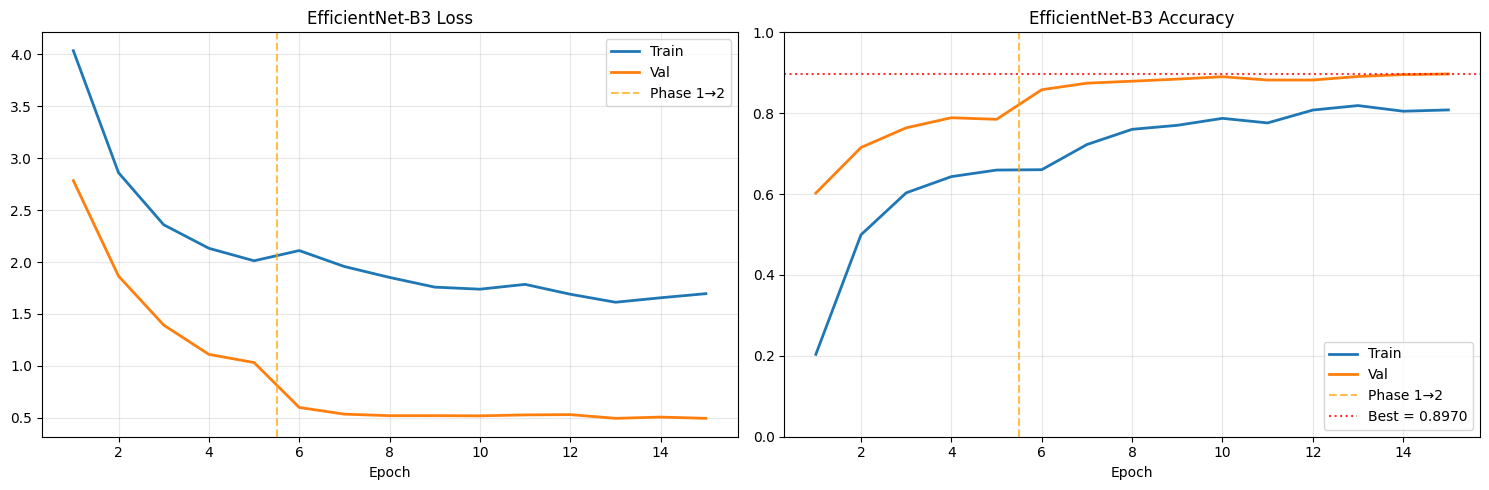

Лучший val_acc: 0.8970 (89.70%)


In [19]:
# Рисуем loss и accuracy по эпохам. Вертикальная линия — граница между фазой 1 и 2.
epochs_range = np.arange(1, len(history['train_loss']) + 1)
p1_boundary  = PHASE1_EPOCHS

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (tr_key, vl_key), title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Loss', 'Accuracy']
):
    ax.plot(epochs_range, history[tr_key], label='Train', linewidth=2)
    ax.plot(epochs_range, history[vl_key], label='Val',   linewidth=2)
    ax.axvline(p1_boundary + 0.5, color='orange', linestyle='--',
               alpha=0.7, label='Phase 1→2')
    ax.set_xlabel('Epoch')
    ax.set_title(f'EfficientNet-B3 {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

best_val = max(history['val_acc'])
axes[1].axhline(best_val, color='red', linestyle=':', alpha=0.8,
                label=f'Best = {best_val:.4f}')
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Лучший val_acc: {best_val:.4f} ({best_val*100:.2f}%)')

In [21]:
# F1-score по каждой породе. Смотрим, какие классы модель путает чаще всего.
from sklearn.metrics import classification_report

report = classification_report(
    tta_labels, tta_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class  = {c: report[c]['f1-score'] for c in class_names if c in report}
sorted_cls = sorted(per_class.items(), key=lambda x: x[1], reverse=True)

print('Топ-5 ЛУЧШИХ классов (F1):')
for c, s in sorted_cls[:5]:
    print(f'  {c.replace("_"," "):<30} {s:.3f}')

print('\nТоп-5 ХУДШИХ классов (F1):')
for c, s in sorted_cls[-5:]:
    print(f'  {c.replace("_"," "):<30} {s:.3f}')

print(f'\nMacro F1    : {report["macro avg"]["f1-score"]:.4f}')
print(f'Weighted F1 : {report["weighted avg"]["f1-score"]:.4f}')

Топ-5 ЛУЧШИХ классов (F1):
  african hunting dog            1.000
  flat coated retriever          1.000
  gordon setter                  1.000
  irish setter                   1.000
  keeshond                       1.000

Топ-5 ХУДШИХ классов (F1):
  collie                         0.667
  siberian husky                 0.644
  american staffordshire terrier 0.593
  english foxhound               0.538
  eskimo dog                     0.207

Macro F1    : 0.8838
Weighted F1 : 0.8862


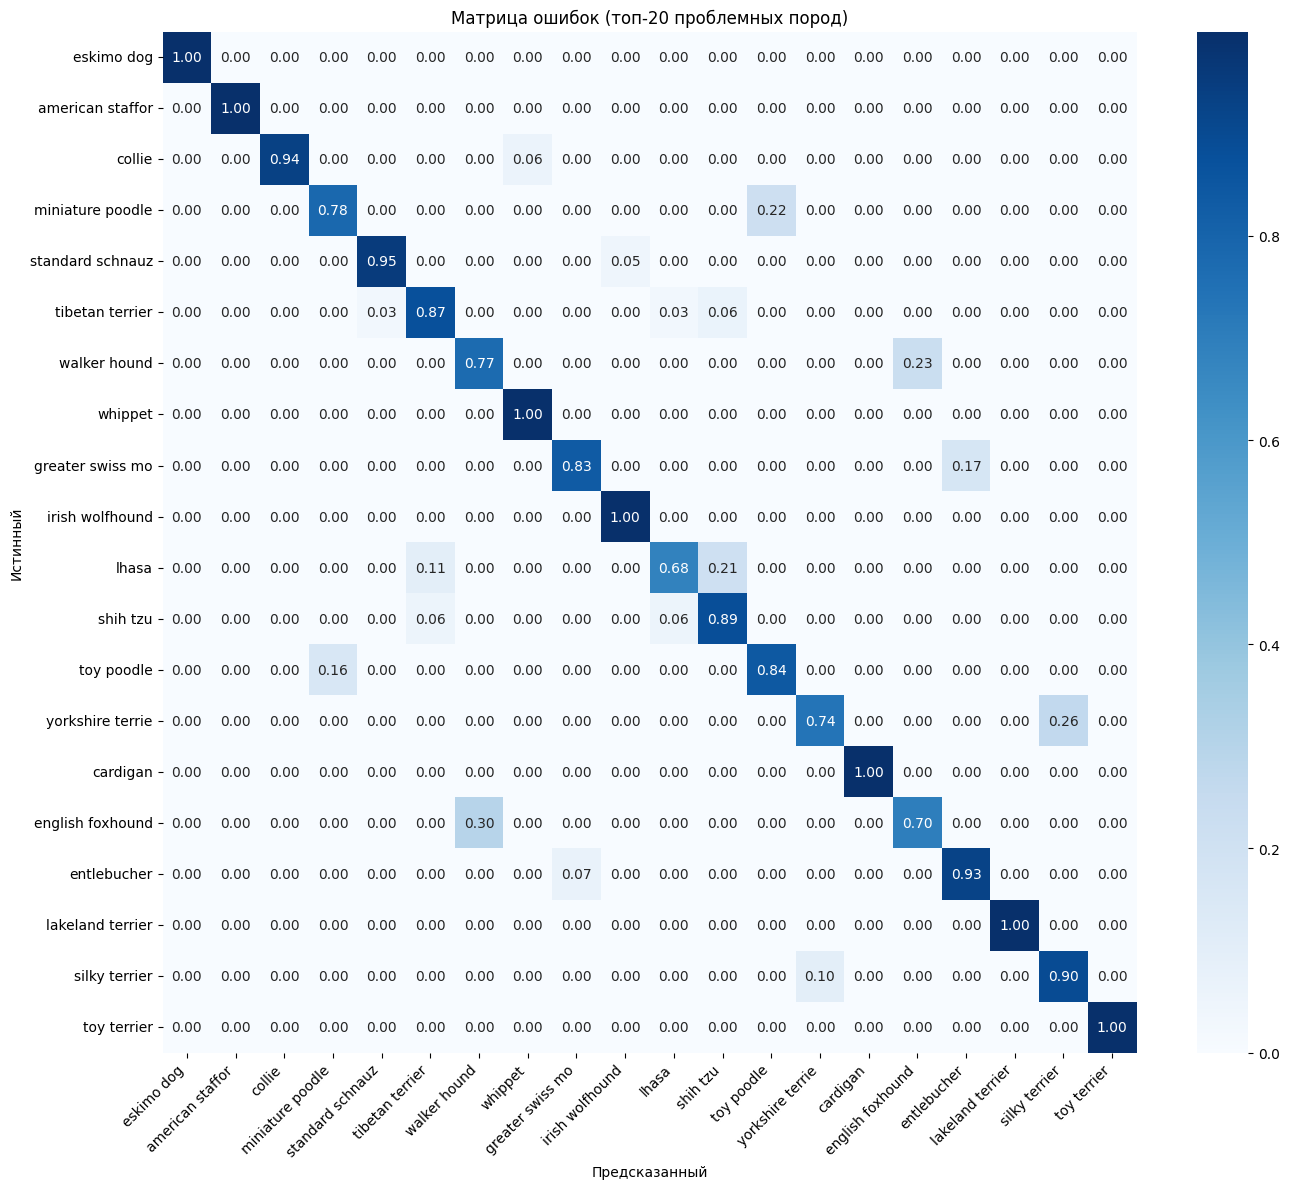

In [22]:
# Матрица ошибок для 20 пород с наибольшим числом неправильных предсказаний.
from sklearn.metrics import confusion_matrix
import seaborn as sns

errors = {i: (tta_preds[tta_labels == i] != i).sum()
          for i in range(num_classes) if (tta_labels == i).sum() > 0}
top20_idx   = [i for i, _ in sorted(errors.items(), key=lambda x: x[1], reverse=True)[:20]]
top20_names = [class_names[i] for i in top20_idx]

mask   = np.isin(tta_labels, top20_idx)
remap  = {old: new for new, old in enumerate(top20_idx)}
y_true = np.array([remap.get(l, -1) for l in tta_labels[mask]])
y_pred = np.array([remap.get(p, -1) for p in tta_preds[mask]])
valid  = (y_true >= 0) & (y_pred >= 0)

cm      = confusion_matrix(y_true[valid], y_pred[valid])
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)
labels  = [n.replace('_',' ')[:16] for n in top20_names]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Матрица ошибок (топ-20 проблемных пород)')
plt.ylabel('Истинный')
plt.xlabel('Предсказанный')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

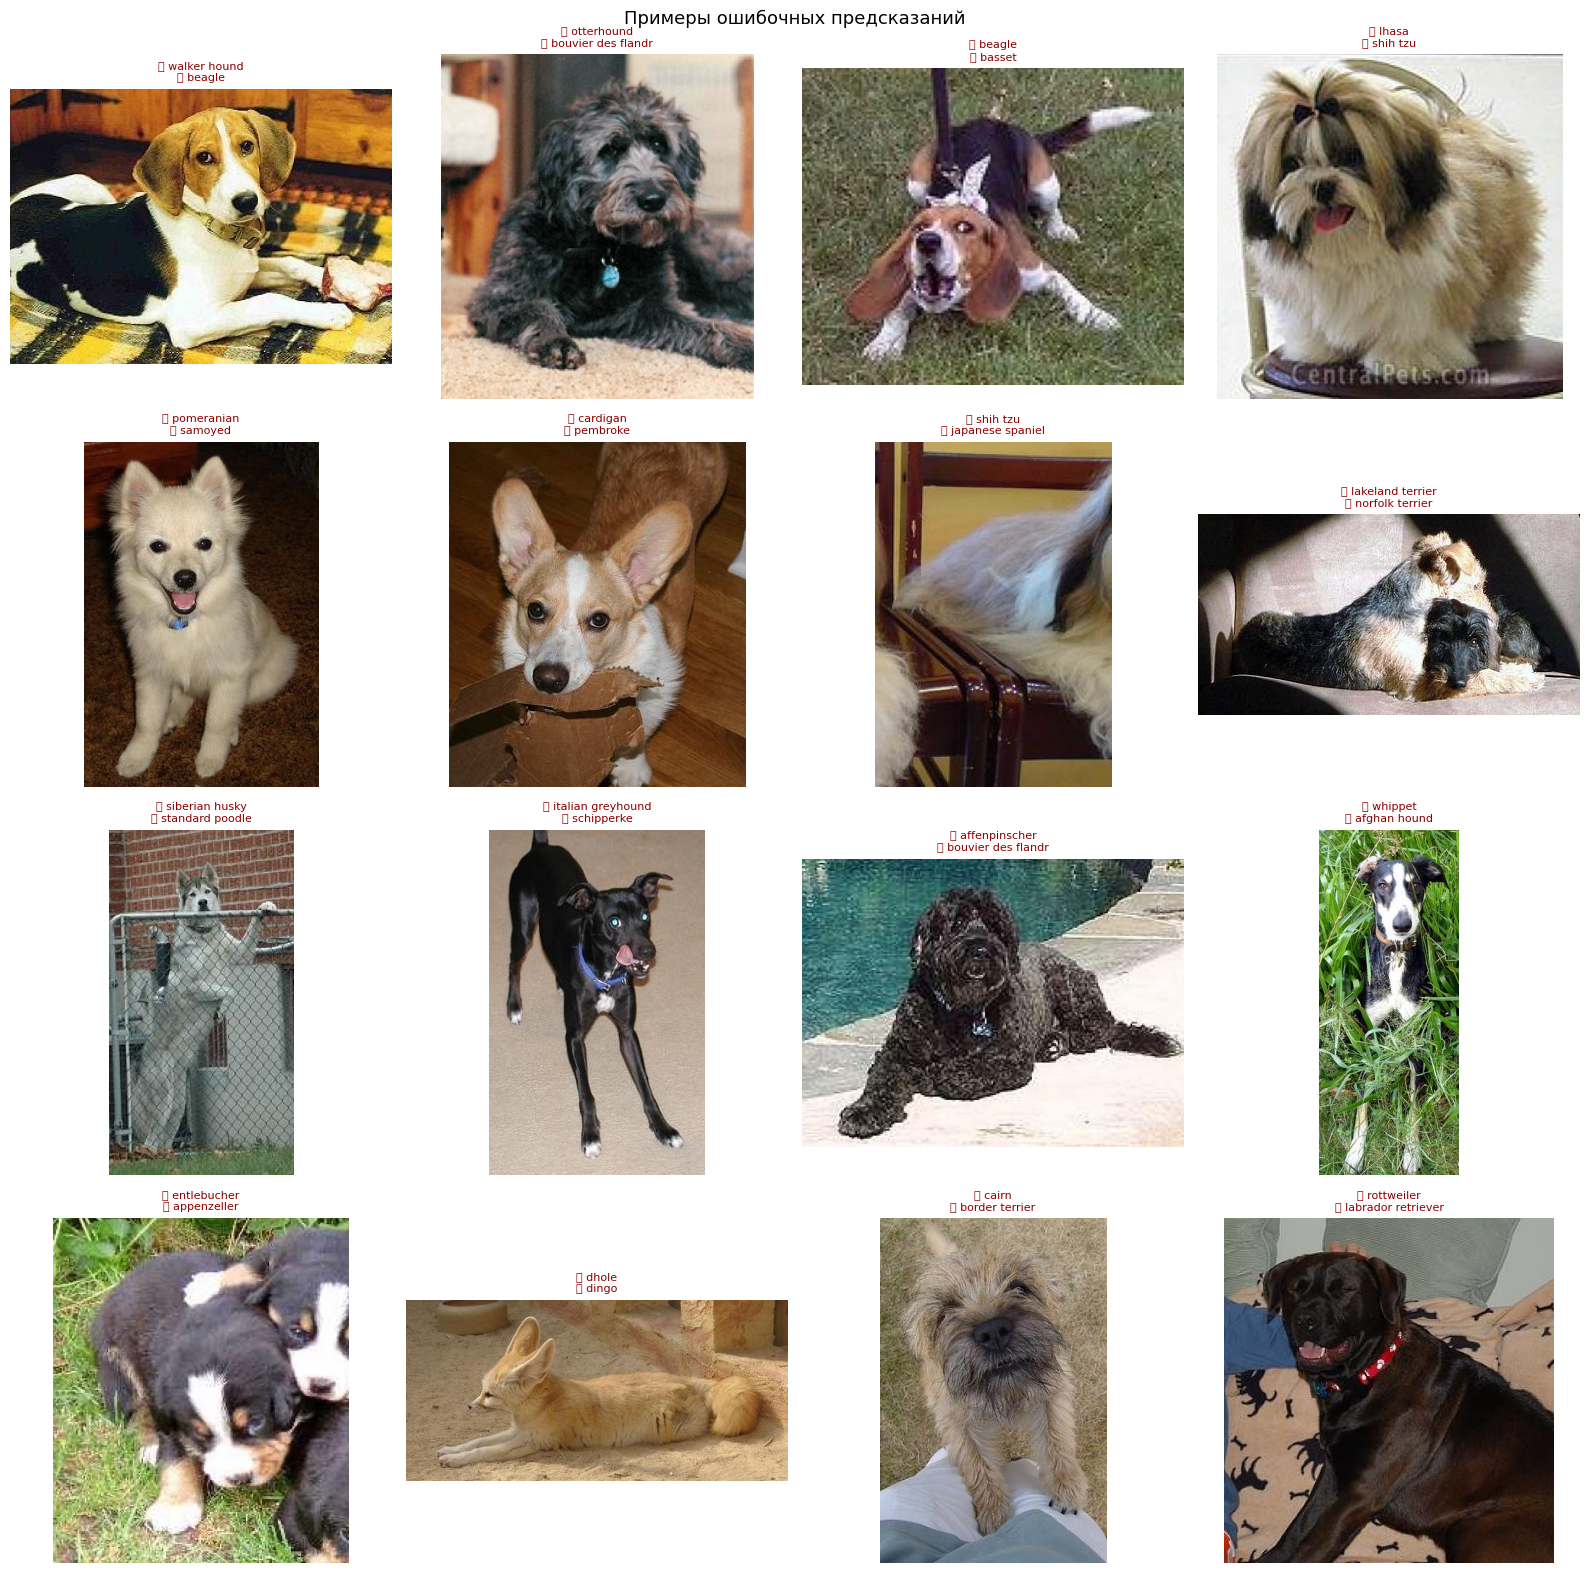

In [23]:
# Показываем 16 примеров ошибок: правильный ответ и предсказание модели.
wrong = np.where(tta_preds != tta_labels)[0][:16]
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for ax, wi in zip(axes.flatten(), wrong):
    img, _ = test_dataset.dataset[test_dataset.indices[wi]]
    true_nm = class_names[tta_labels[wi]].replace('_',' ')
    pred_nm = class_names[tta_preds[wi]].replace('_',' ')
    ax.imshow(img)
    ax.set_title(f' {true_nm[:18]}\n {pred_nm[:18]}', fontsize=8, color='darkred')
    ax.axis('off')

plt.suptitle('Примеры ошибочных предсказаний', fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/prediction_errors.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Сохраняем веса модели, список классов и метрики в /content/dog_breed_model/.

save_dir = f'{BASE_DIR}/dog_breed_model'
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), f'{save_dir}/efficientnet_b3_dogs.pt')

with open(f'{save_dir}/class_names.json', 'w') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

metrics_dict = {
    'best_val_acc': round(max(history['val_acc']), 4),
    'test_acc':     round(float(test_acc), 4),
    'test_acc_tta': round(float(tta_acc), 4),
    'num_classes':  num_classes,
    'backbone':     'efficientnet_b3',
    'img_size':     IMG_SIZE,
    'dataset_size': len(base_dataset),
    'used_tsinghua': USE_TSINGHUA,
}
with open(f'{save_dir}/metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print('Сохранено в', save_dir)
for fn in os.listdir(save_dir):
    sz = os.path.getsize(os.path.join(save_dir, fn)) / 1024 / 1024
    print(f'  {fn}  ({sz:.1f} MB)')

print('\n Итоговые метрики:')
for k, v in metrics_dict.items():
    print(f'  {k}: {v}')


📊 Итоговые метрики:
  best_val_acc: 0.897
  test_acc: 0.8905
  test_acc_tta: 0.8883
  num_classes: 120
  backbone: efficientnet_b3
  img_size: 300
  dataset_size: 20580
  used_tsinghua: False


In [25]:
# Скачиваем сохранённые файлы на локальный компьютер через браузер.
from google.colab import files
files.download(f'{save_dir}/efficientnet_b3_dogs.pt')
files.download(f'{save_dir}/class_names.json')
files.download(f'{save_dir}/metrics.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

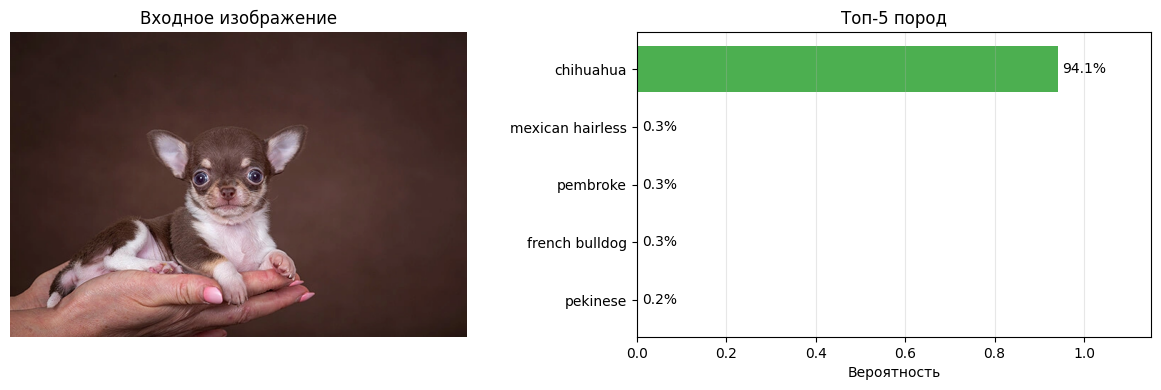


Результат: chihuahua (94.1%)


In [27]:
# Принимает путь к файлу или URL. Возвращает топ-5 пород с вероятностями.
@torch.no_grad()
def predict_breed(image_path_or_url, model, class_names, device, top_k=5):
    """
    Определяет породу собаки.
    Принимает: путь к файлу или URL изображения.
    """
    if image_path_or_url.startswith('http'):
        import urllib.request
        tmp = '/tmp/dog_test.jpg'
        urllib.request.urlretrieve(image_path_or_url, tmp)
        img = Image.open(tmp).convert('RGB')
    else:
        img = Image.open(image_path_or_url).convert('RGB')

    tensor = val_transform(img).unsqueeze(0).to(device)
    model.eval()
    probs     = F.softmax(model(tensor), dim=1)[0]
    top_p, top_i = probs.topk(top_k)
    results   = [(class_names[i].replace('_',' '), p.item()) for i, p in zip(top_i, top_p)]

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
    ax_img.imshow(img)
    ax_img.axis('off')
    ax_img.set_title('Входное изображение')

    breeds = [r[0] for r in results]
    probs_v = [r[1] for r in results]
    colors  = ['#4CAF50'] + ['#2196F3'] * (top_k - 1)
    ax_bar.barh(breeds[::-1], probs_v[::-1], color=colors[::-1])
    for i, (breed, prob) in enumerate(zip(breeds[::-1], probs_v[::-1])):
        ax_bar.text(prob + 0.01, i, f'{prob:.1%}', va='center', fontsize=10)
    ax_bar.set_xlim([0, 1.15])
    ax_bar.set_xlabel('Вероятность')
    ax_bar.set_title(f'Топ-{top_k} пород')
    ax_bar.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f'\n Результат: {results[0][0]} ({results[0][1]:.1%})')
    return results

# Пример: тестируем на случайном фото из интернета
predict_breed(
    'https://s0.rbk.ru/v6_top_pics/media/img/3/03/347074639984033.webp',
    model, class_names, device
)

# Или загрузи своё фото:
# from google.colab import files
# uploaded = files.upload()
# predict_breed(list(uploaded.keys())[0], model, class_names, device)